In [1]:
# ---------------------- CELL 1: Install Compatible Versions ----------------------
# Uninstall any existing conflicting packages
!pip uninstall -y langchain langchain-community paddlepaddle paddlepaddle-gpu paddleocr paddlex

# Install langchain 0.0.345 (needed for paddlex imports)
!pip install langchain==0.0.345

# Install paddlepaddle (CPU version, compatible with Colab)
!pip install paddlepaddle==2.6.2

# Install paddleocr 2.9.1 (compatible with paddle 2.6.2)
!pip install paddleocr==2.9.1

# Force-reinstall langchain to ensure it stays at 0.0.345
!pip install langchain==0.0.345 --force-reinstall

# Set environment variable to skip model source check
import os
os.environ['PADDLE_PDX_DISABLE_MODEL_SOURCE_CHECK'] = 'True'

# Verify installed versions
import langchain
import paddle
import paddleocr

print(f"✅ langchain version: {langchain.__version__}")
print(f"✅ paddlepaddle version: {paddle.__version__}")
print(f"✅ paddleocr version: {paddleocr.__version__}")

print("\n⚠️  IMPORTANT: Now go to Runtime → Restart runtime, then run the remaining cells.")

Found existing installation: langchain 0.0.345
Uninstalling langchain-0.0.345:
  Successfully uninstalled langchain-0.0.345
Found existing installation: paddleocr 2.8.1
Uninstalling paddleocr-2.8.1:
  Successfully uninstalled paddleocr-2.8.1
Found existing installation: paddlex 3.4.2
Uninstalling paddlex-3.4.2:
  Successfully uninstalled paddlex-3.4.2
  Using cached langchain-0.0.345-py3-none-any.whl.metadata (16 kB)
Using cached langchain-0.0.345-py3-none-any.whl (2.0 MB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 125.9/125.9 MB 5.9 MB/s eta 0:00:00
INFO: pip is looking at multiple versions of opencv-python-headless to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 544.7/544.7 kB 11.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 161.9/161.9 kB 9.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.0/50.0 MB 8.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 

✅ langchain version: 0.0.345
✅ paddlepaddle version: 2.6.2
✅ paddleocr version: 2.9.1

⚠️  IMPORTANT: Now go to Runtime → Restart runtime, then run the remaining cells.


# Import Modules

In [1]:
# ---------------------- CELL 2: Imports ----------------------
from paddleocr import PaddleOCR
import numpy as np
from PIL import Image, ImageFilter, ImageOps, ImageEnhance
import cv2
from google.colab.patches import cv2_imshow
from IPython.display import display
import os

print("✅ Modules imported.")

✅ Modules imported.


In [2]:
# For paddleocr 2.9.1, the parameter is `use_angle_cls` (same as before)
ocr = PaddleOCR(use_angle_cls=True, lang='en')
print("✅ PaddleOCR reader created.")

download https://paddleocr.bj.bcebos.com/PP-OCRv3/english/en_PP-OCRv3_det_infer.tar to /root/.paddleocr/whl/det/en/en_PP-OCRv3_det_infer/en_PP-OCRv3_det_infer.tar


100%|██████████| 3910/3910 [00:00<00:00, 9384.99it/s] 


download https://paddleocr.bj.bcebos.com/PP-OCRv4/english/en_PP-OCRv4_rec_infer.tar to /root/.paddleocr/whl/rec/en/en_PP-OCRv4_rec_infer/en_PP-OCRv4_rec_infer.tar


100%|██████████| 10000/10000 [00:00<00:00, 18556.41it/s]


download https://paddleocr.bj.bcebos.com/dygraph_v2.0/ch/ch_ppocr_mobile_v2.0_cls_infer.tar to /root/.paddleocr/whl/cls/ch_ppocr_mobile_v2.0_cls_infer/ch_ppocr_mobile_v2.0_cls_infer.tar


100%|██████████| 2138/2138 [00:00<00:00, 6523.80it/s]

[2026/03/09 01:35:25] ppocr DEBUG: Namespace(help='==SUPPRESS==', use_gpu=False, use_xpu=False, use_npu=False, use_mlu=False, ir_optim=True, use_tensorrt=False, min_subgraph_size=15, precision='fp32', gpu_mem=500, gpu_id=0, image_dir=None, page_num=0, det_algorithm='DB', det_model_dir='/root/.paddleocr/whl/det/en/en_PP-OCRv3_det_infer', det_limit_side_len=960, det_limit_type='max', det_box_type='quad', det_db_thresh=0.3, det_db_box_thresh=0.6, det_db_unclip_ratio=1.5, max_batch_size=10, use_dilation=False, det_db_score_mode='fast', det_east_score_thresh=0.8, det_east_cover_thresh=0.1, det_east_nms_thresh=0.2, det_sast_score_thresh=0.5, det_sast_nms_thresh=0.2, det_pse_thresh=0, det_pse_box_thresh=0.85, det_pse_min_area=16, det_pse_scale=1, scales=[8, 16, 32], alpha=1.0, beta=1.0, fourier_degree=5, rec_algorithm='SVTR_LCNet', rec_model_dir='/root/.paddleocr/whl/rec/en/en_PP-OCRv4_rec_infer', rec_image_inverse=True, rec_image_shape='3, 48, 320', rec_batch_num=6, max_text_length=25, rec_c

✅ PaddleOCR reader created.


# Define Transformation Functions

In [3]:
# All functions take a PIL Image and return a transformed PIL Image.

def rotate_image(img, angle=5):
    """Rotate image by given angle (degrees)."""
    return img.rotate(angle, expand=True, fillcolor=(255,255,255))

def skew_image(img, shear=0.2):
    """Apply horizontal shear (skew)."""
    arr = np.array(img)
    h, w = arr.shape[:2]
    M = np.float32([[1, shear, 0], [0, 1, 0]])
    new_w = int(w + abs(shear) * h)
    sheared = cv2.warpAffine(arr, M, (new_w, h), borderMode=cv2.BORDER_CONSTANT, borderValue=(255,255,255))
    return Image.fromarray(sheared)

def blur_image(img, radius=2):
    """Apply Gaussian blur."""
    return img.filter(ImageFilter.GaussianBlur(radius=radius))

def add_noise(img, intensity=25):
    """Add random Gaussian noise."""
    arr = np.array(img).astype(np.float32)
    noise = np.random.normal(0, intensity, arr.shape)
    noisy = np.clip(arr + noise, 0, 255).astype(np.uint8)
    return Image.fromarray(noisy)

def adjust_brightness(img, factor=1.5):
    """Change brightness (factor >1 brighter, <1 darker)."""
    enhancer = ImageEnhance.Brightness(img)
    return enhancer.enhance(factor)

def adjust_contrast(img, factor=1.5):
    """Change contrast."""
    enhancer = ImageEnhance.Contrast(img)
    return enhancer.enhance(factor)

def resize_image(img, scale=0.7):
    """Resize image (scale <1 smaller, >1 larger)."""
    new_size = (int(img.width * scale), int(img.height * scale))
    return img.resize(new_size, Image.Resampling.LANCZOS)

def invert_colors(img):
    """Invert image colors."""
    return ImageOps.invert(img.convert('RGB'))

def perspective_warp(img, strength=0.05):
    """
    Apply a weak perspective distortion.
    """
    w, h = img.size
    src = np.float32([[0,0], [w-1,0], [0,h-1], [w-1,h-1]])
    dst = src + strength * np.random.uniform(-h, h, src.shape)
    dst = dst.astype(np.float32)
    matrix = cv2.getPerspectiveTransform(src, dst)
    arr = np.array(img)
    warped = cv2.warpPerspective(arr, matrix, (w, h), borderMode=cv2.BORDER_CONSTANT, borderValue=(255,255,255))
    return Image.fromarray(warped)

# Load Your Image

✅ Image found at /content/Text_image.webp
📸 Original Image:


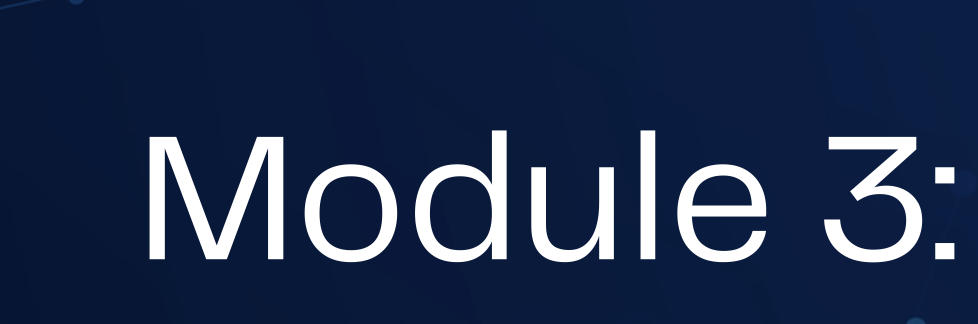

In [5]:
image_path = '/content/Text_image.webp'   # <-- CHANGE THIS TO YOUR IMAGE PATH

if not os.path.exists(image_path):
    print(f"❌ Image not found at {image_path}. Please upload your image and update the path.")
    from google.colab import files
    print("Upload your image now:")
    uploaded = files.upload()
    for fn in uploaded.keys():
        image_path = f"/content/{fn}"
        print(f"✅ Using uploaded file: {image_path}")
        break
else:
    print(f"✅ Image found at {image_path}")

# Load the original image
original_img = Image.open(image_path).convert('RGB')
print("📸 Original Image:")
display(original_img)

# Generate Variations

In [6]:
variations = []

# Always keep the original as first
variations.append((original_img, "Original"))

# Add variations (you can add/remove or change parameters)
variations.append((rotate_image(original_img, 5), "Rotated +5°"))
variations.append((rotate_image(original_img, -5), "Rotated -5°"))
variations.append((rotate_image(original_img, 15), "Rotated +15°"))
variations.append((skew_image(original_img, 0.2), "Skewed (shear)"))
variations.append((blur_image(original_img, 2), "Blurred"))
variations.append((add_noise(original_img, 30), "With Noise"))
variations.append((adjust_brightness(original_img, 1.8), "Brighter"))
variations.append((adjust_brightness(original_img, 0.5), "Darker"))
variations.append((adjust_contrast(original_img, 2.0), "High Contrast"))
variations.append((resize_image(original_img, 0.5), "Resized 50%"))
variations.append((invert_colors(original_img), "Inverted Colors"))
variations.append((perspective_warp(original_img, 0.03), "Perspective Warp"))

print(f"✅ Created {len(variations)} image variations.")

✅ Created 13 image variations.


# Run PaddleOCR on Each Variation and Display


--- Variation 1: Original ---


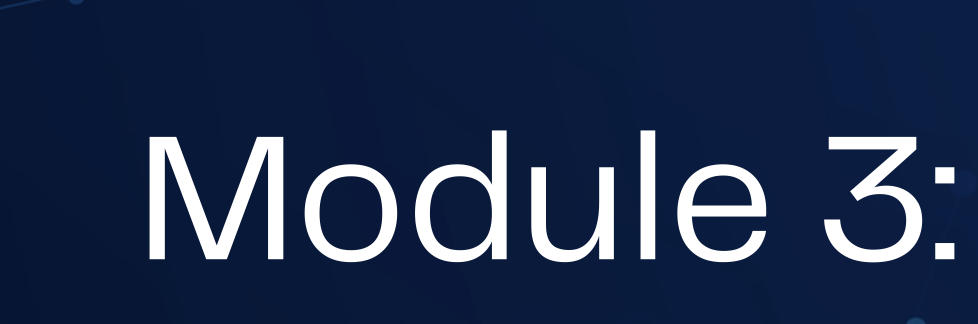

[2026/03/09 01:36:35] ppocr DEBUG: dt_boxes num : 1, elapsed : 0.4385108947753906
[2026/03/09 01:36:35] ppocr DEBUG: cls num  : 1, elapsed : 0.037107229232788086
[2026/03/09 01:36:35] ppocr DEBUG: rec_res num  : 1, elapsed : 0.14406180381774902
📝 Extracted text: Module 3:
----------------------------------------

--- Variation 2: Rotated +5° ---


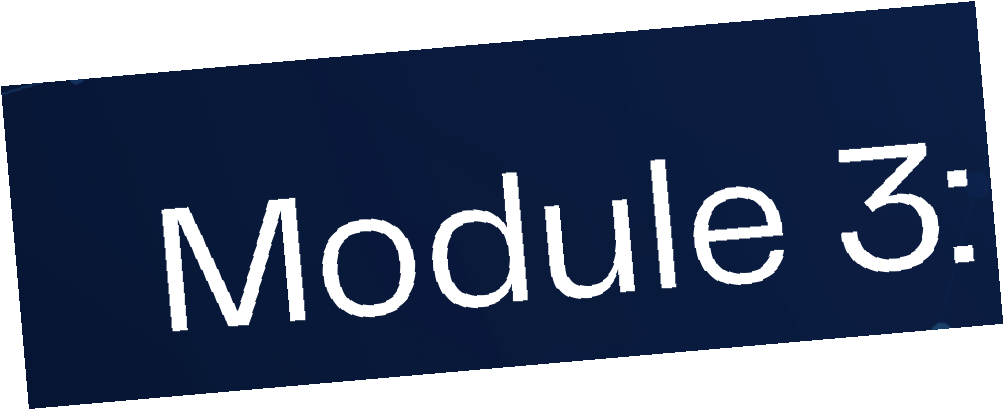

[2026/03/09 01:36:36] ppocr DEBUG: dt_boxes num : 1, elapsed : 0.5718958377838135
[2026/03/09 01:36:36] ppocr DEBUG: cls num  : 1, elapsed : 0.013295412063598633
[2026/03/09 01:36:36] ppocr DEBUG: rec_res num  : 1, elapsed : 0.0870962142944336
📝 Extracted text: Module 3:
----------------------------------------

--- Variation 3: Rotated -5° ---


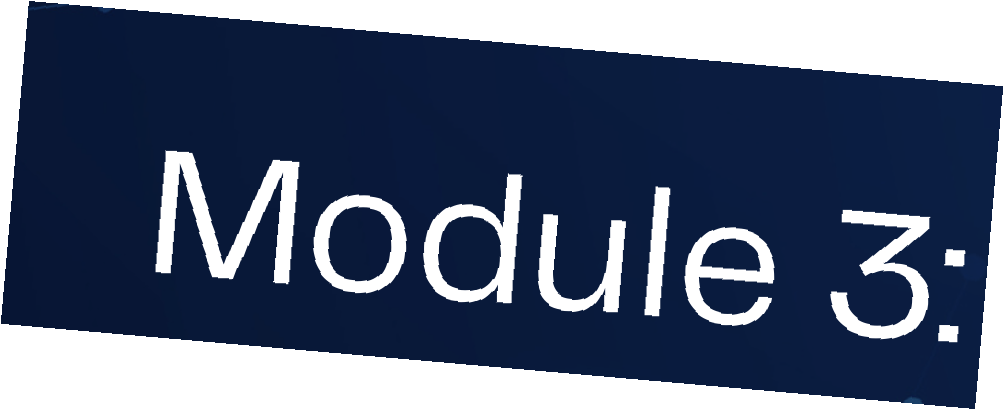

[2026/03/09 01:36:36] ppocr DEBUG: dt_boxes num : 1, elapsed : 0.1738431453704834
[2026/03/09 01:36:36] ppocr DEBUG: cls num  : 1, elapsed : 0.019114971160888672
[2026/03/09 01:36:36] ppocr DEBUG: rec_res num  : 1, elapsed : 0.07744598388671875
📝 Extracted text: Module 3:
----------------------------------------

--- Variation 4: Rotated +15° ---


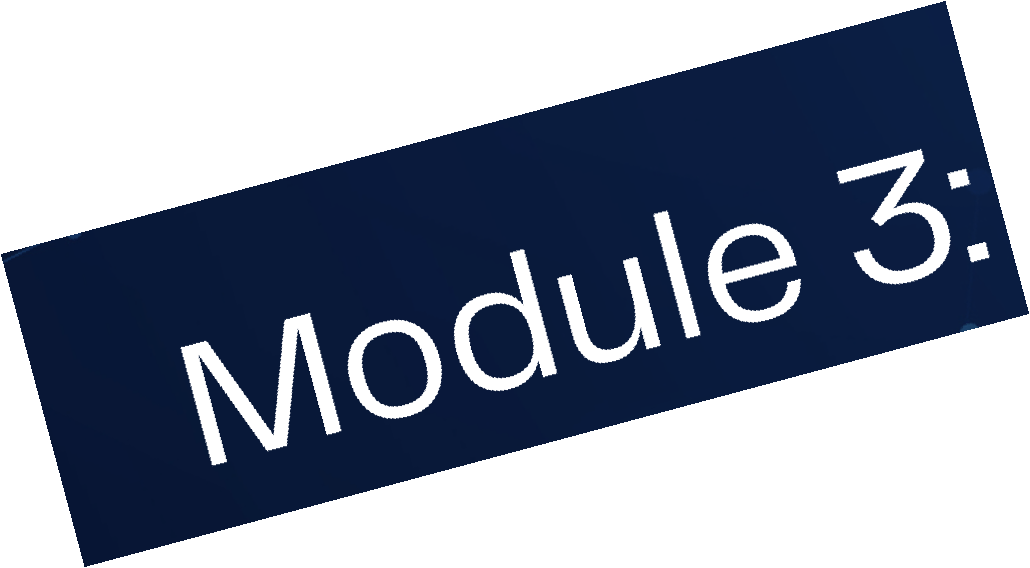

[2026/03/09 01:36:37] ppocr DEBUG: dt_boxes num : 1, elapsed : 0.6885669231414795
[2026/03/09 01:36:37] ppocr DEBUG: cls num  : 1, elapsed : 0.016422510147094727
[2026/03/09 01:36:37] ppocr DEBUG: rec_res num  : 1, elapsed : 0.08892273902893066
📝 Extracted text: Module 3:
----------------------------------------

--- Variation 5: Skewed (shear) ---


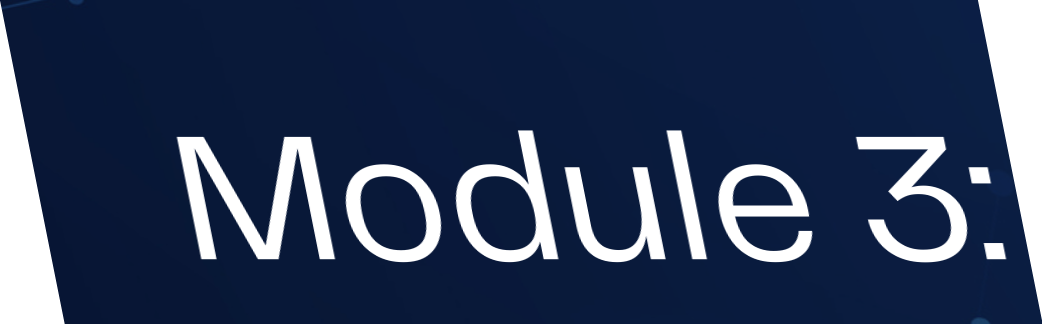

[2026/03/09 01:36:38] ppocr DEBUG: dt_boxes num : 1, elapsed : 0.31052517890930176
[2026/03/09 01:36:38] ppocr DEBUG: cls num  : 1, elapsed : 0.026006460189819336
[2026/03/09 01:36:38] ppocr DEBUG: rec_res num  : 1, elapsed : 0.0942695140838623
📝 Extracted text: Module 3:
----------------------------------------

--- Variation 6: Blurred ---


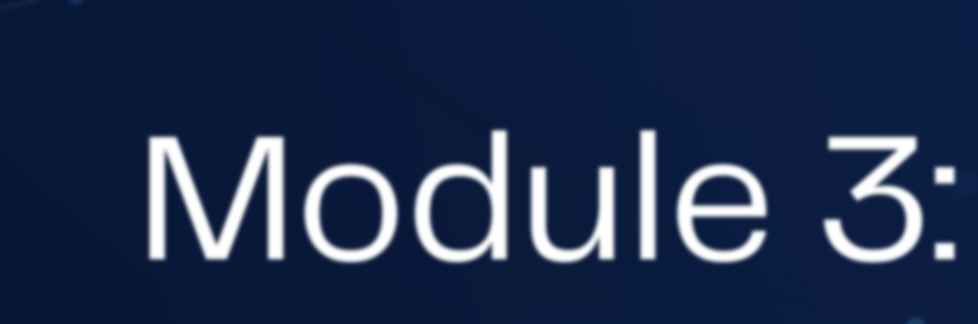

[2026/03/09 01:36:38] ppocr DEBUG: dt_boxes num : 1, elapsed : 0.1553206443786621
[2026/03/09 01:36:38] ppocr DEBUG: cls num  : 1, elapsed : 0.01726698875427246
[2026/03/09 01:36:38] ppocr DEBUG: rec_res num  : 1, elapsed : 0.08318972587585449
📝 Extracted text: Module 3:
----------------------------------------

--- Variation 7: With Noise ---


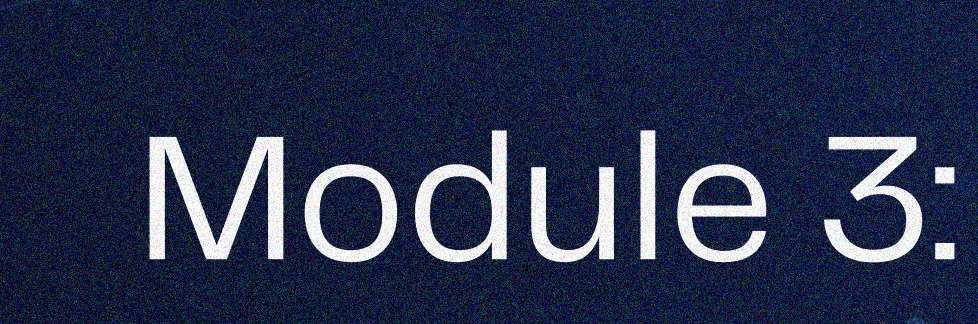

[2026/03/09 01:36:38] ppocr DEBUG: dt_boxes num : 1, elapsed : 0.20581603050231934
[2026/03/09 01:36:38] ppocr DEBUG: cls num  : 1, elapsed : 0.02506709098815918
[2026/03/09 01:36:39] ppocr DEBUG: rec_res num  : 1, elapsed : 0.1797933578491211
📝 Extracted text: Module 3:
----------------------------------------

--- Variation 8: Brighter ---


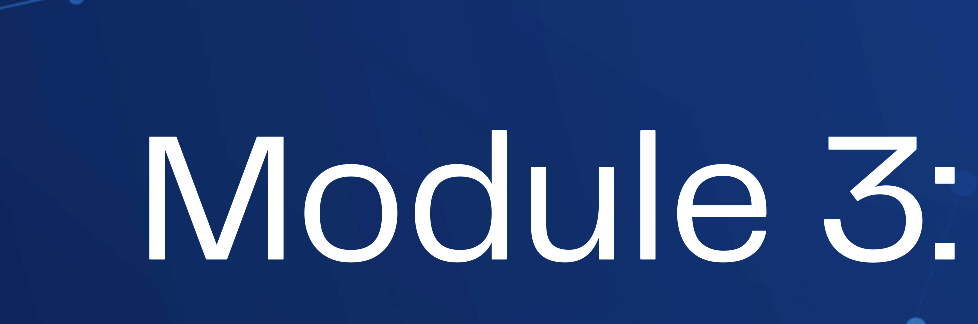

[2026/03/09 01:36:39] ppocr DEBUG: dt_boxes num : 1, elapsed : 0.2337336540222168
[2026/03/09 01:36:39] ppocr DEBUG: cls num  : 1, elapsed : 0.030571937561035156
[2026/03/09 01:36:39] ppocr DEBUG: rec_res num  : 1, elapsed : 0.14621710777282715
📝 Extracted text: Module 3:
----------------------------------------

--- Variation 9: Darker ---


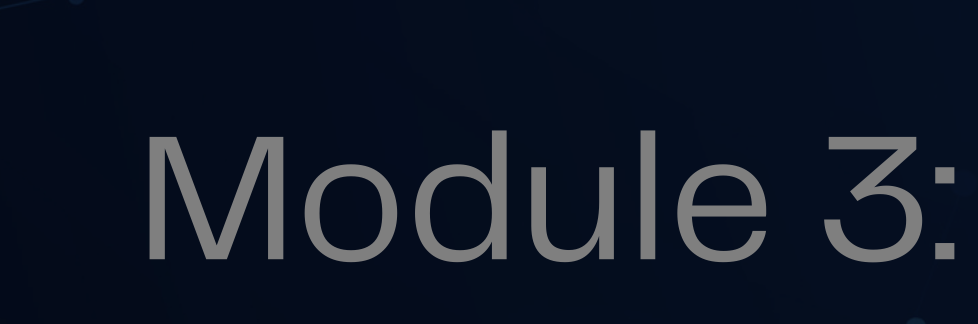

[2026/03/09 01:36:39] ppocr DEBUG: dt_boxes num : 1, elapsed : 0.23865365982055664
[2026/03/09 01:36:39] ppocr DEBUG: cls num  : 1, elapsed : 0.02555561065673828
[2026/03/09 01:36:40] ppocr DEBUG: rec_res num  : 1, elapsed : 0.11519718170166016
📝 Extracted text: Module 3z
----------------------------------------

--- Variation 10: High Contrast ---


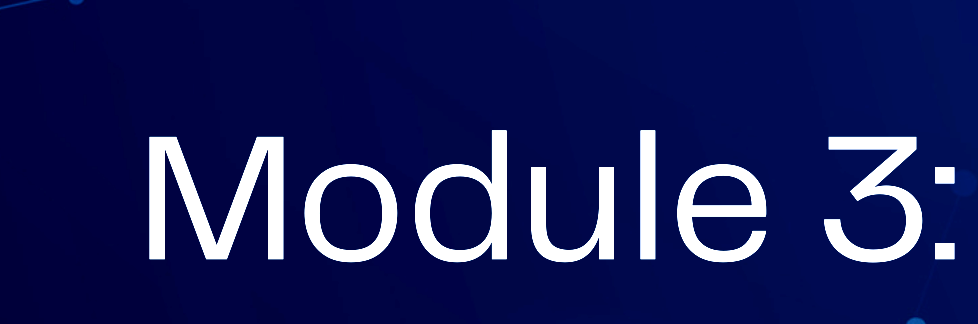

[2026/03/09 01:36:40] ppocr DEBUG: dt_boxes num : 1, elapsed : 0.22761011123657227
[2026/03/09 01:36:40] ppocr DEBUG: cls num  : 1, elapsed : 0.018158435821533203
[2026/03/09 01:36:40] ppocr DEBUG: rec_res num  : 1, elapsed : 0.11768484115600586
📝 Extracted text: Module 3:
----------------------------------------

--- Variation 11: Resized 50% ---


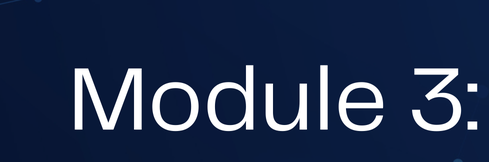

[2026/03/09 01:36:40] ppocr DEBUG: dt_boxes num : 1, elapsed : 0.2200307846069336
[2026/03/09 01:36:40] ppocr DEBUG: cls num  : 1, elapsed : 0.017363309860229492
[2026/03/09 01:36:41] ppocr DEBUG: rec_res num  : 1, elapsed : 0.24784493446350098
📝 Extracted text: Module 3:
----------------------------------------

--- Variation 12: Inverted Colors ---


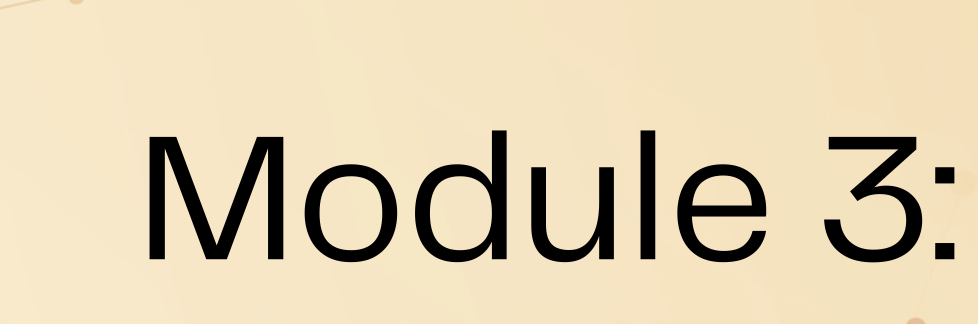

[2026/03/09 01:36:41] ppocr DEBUG: dt_boxes num : 1, elapsed : 0.26337099075317383
[2026/03/09 01:36:41] ppocr DEBUG: cls num  : 1, elapsed : 0.01809072494506836
[2026/03/09 01:36:41] ppocr DEBUG: rec_res num  : 1, elapsed : 0.13176441192626953
📝 Extracted text: Module 3:
----------------------------------------

--- Variation 13: Perspective Warp ---


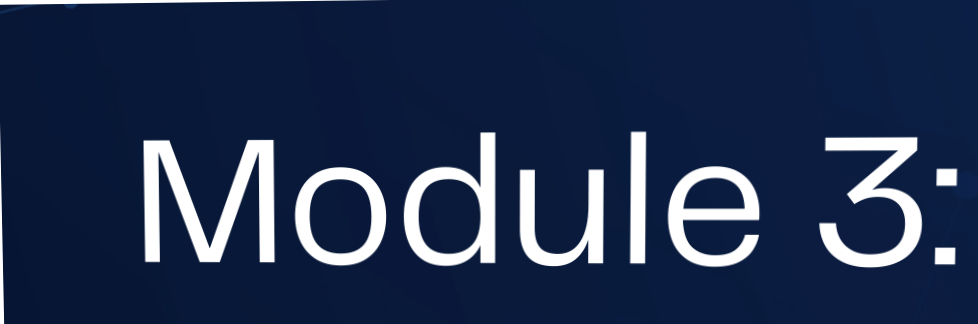

[2026/03/09 01:36:41] ppocr DEBUG: dt_boxes num : 1, elapsed : 0.20427775382995605
[2026/03/09 01:36:41] ppocr DEBUG: cls num  : 1, elapsed : 0.025688648223876953
[2026/03/09 01:36:41] ppocr DEBUG: rec_res num  : 1, elapsed : 0.1326131820678711
📝 Extracted text: Module 3:
----------------------------------------

✅ Done.


In [7]:
for idx, (img, desc) in enumerate(variations, 1):
    print(f"\n--- Variation {idx}: {desc} ---")

    # Display image
    display(img)

    # Convert PIL image to numpy array (PaddleOCR expects numpy array or path)
    img_np = np.array(img)

    # Run PaddleOCR
    try:
        # PaddleOCR returns a list: each element is [box, (text, confidence)]
        results = ocr.ocr(img_np, cls=True)  # cls=True enables angle classification
        if results and results[0]:  # Check if any text detected
            # results[0] is list of detections for the first image (since we passed one image)
            texts = [item[1][0] for item in results[0]]  # item[1][0] is the text
            extracted = ' '.join(texts)
            print(f"📝 Extracted text: {extracted}")
            # Optionally show confidence
            # for item in results[0]:
            #     print(f"   {item[1][0]} (confidence: {item[1][1]:.2f})")
        else:
            print("📝 No text detected")
    except Exception as e:
        print(f"❌ OCR failed: {e}")

    print("-" * 40)

print("\n✅ Done.")